Using device: cuda
u_all shape: (1250, 100)
s_all shape: (1250, 100, 100)
Train: (875, 100) (875, 100, 100)
Val  : (125, 100) (125, 100, 100)
Test : (250, 100) (250, 100, 100)

Training FEDONet with mapping_size = 4 (actual Fourier feature dimension = 8)
[INFO] Saving checkpoint to: c:\Users\asojitra\Documents\DeepONets_Serious\Data_generation\Burgers_GRF_initialisation\checkpoints_fourier_sweep\fedonet_ff_4_best.pth
[fedonet_ff_4] Epoch    1/2200 | Train MSE(n): 1.001608e+00 | Val Rel-L2: 1.001099e+00
[fedonet_ff_4] Epoch    2/2200 | Train MSE(n): 1.000199e+00 | Val Rel-L2: 1.000975e+00
[fedonet_ff_4] Epoch    3/2200 | Train MSE(n): 1.000010e+00 | Val Rel-L2: 1.000958e+00
[fedonet_ff_4] Epoch    4/2200 | Train MSE(n): 9.998896e-01 | Val Rel-L2: 1.000952e+00
[fedonet_ff_4] Epoch    5/2200 | Train MSE(n): 9.997776e-01 | Val Rel-L2: 1.000812e+00
[fedonet_ff_4] Epoch    6/2200 | Train MSE(n): 9.989033e-01 | Val Rel-L2: 9.989835e-01
[fedonet_ff_4] Epoch    7/2200 | Train MSE(n): 9.946989e-

C:\Users\asojitra\AppData\Local\Temp\ipykernel_31472\3791158122.py:400: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_data = torch.load(ckpt_path, map_location=device)


[fedonet_ff_8] Epoch    3/2200 | Train MSE(n): 9.999743e-01 | Val Rel-L2: 1.000974e+00
[fedonet_ff_8] Epoch    4/2200 | Train MSE(n): 9.998953e-01 | Val Rel-L2: 1.000969e+00
[fedonet_ff_8] Epoch    5/2200 | Train MSE(n): 9.998367e-01 | Val Rel-L2: 1.000911e+00
[fedonet_ff_8] Epoch    6/2200 | Train MSE(n): 9.995488e-01 | Val Rel-L2: 1.000340e+00
[fedonet_ff_8] Epoch    7/2200 | Train MSE(n): 9.914165e-01 | Val Rel-L2: 9.788240e-01
[fedonet_ff_8] Epoch    8/2200 | Train MSE(n): 9.090919e-01 | Val Rel-L2: 9.357119e-01
[fedonet_ff_8] Epoch    9/2200 | Train MSE(n): 8.122185e-01 | Val Rel-L2: 8.543039e-01
[fedonet_ff_8] Epoch   10/2200 | Train MSE(n): 7.361580e-01 | Val Rel-L2: 8.536832e-01
[fedonet_ff_8] Epoch   11/2200 | Train MSE(n): 7.109229e-01 | Val Rel-L2: 8.344239e-01
[fedonet_ff_8] Epoch   12/2200 | Train MSE(n): 6.887844e-01 | Val Rel-L2: 8.210945e-01
[fedonet_ff_8] Epoch   13/2200 | Train MSE(n): 6.756593e-01 | Val Rel-L2: 8.142722e-01
[fedonet_ff_8] Epoch   14/2200 | Train MSE(

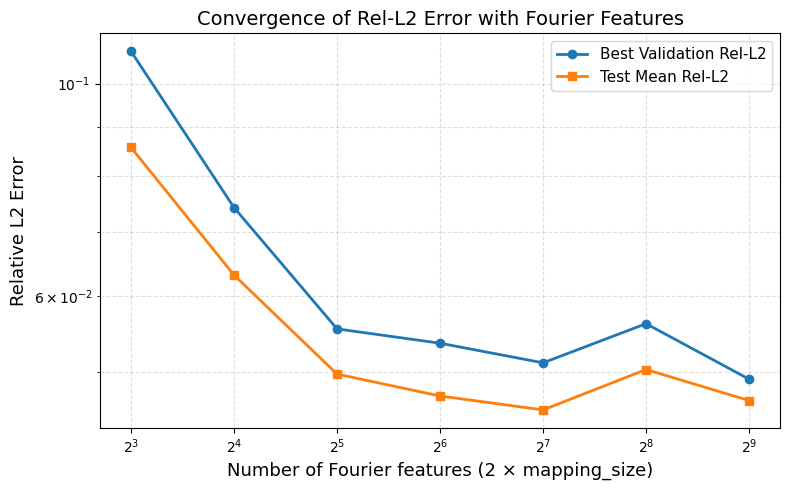

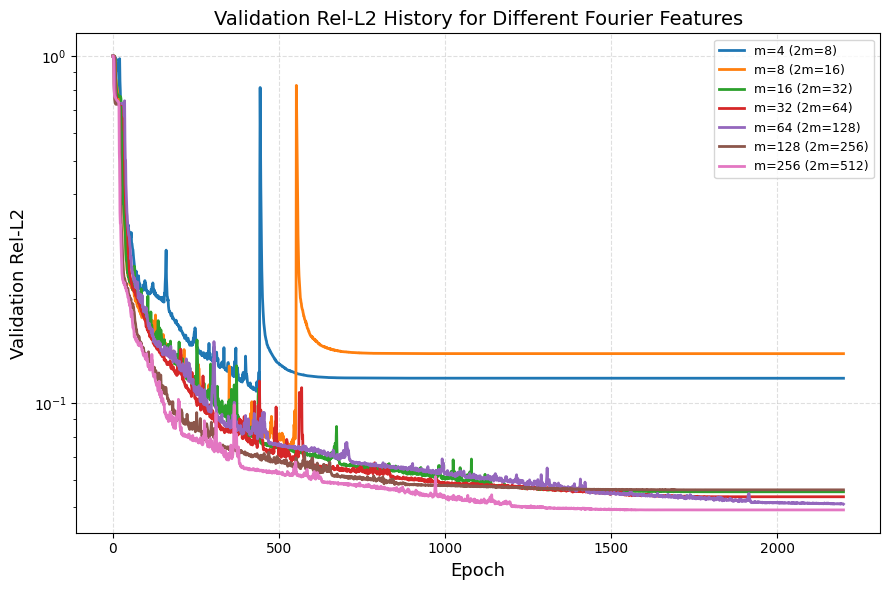

C:\Users\asojitra\AppData\Local\Temp\ipykernel_31472\3791158122.py:508: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_ckpt_data = torch.load(best_ckpt_path, map_locatio


Reloaded best model test mean Rel-L2: 4.562721e-02
Reloaded best model test std  Rel-L2: 3.041675e-02


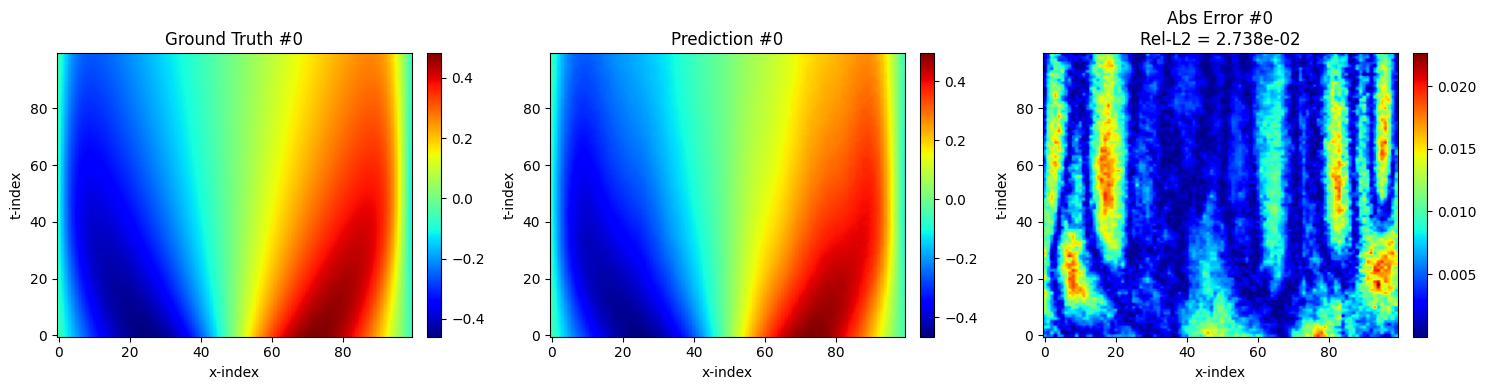

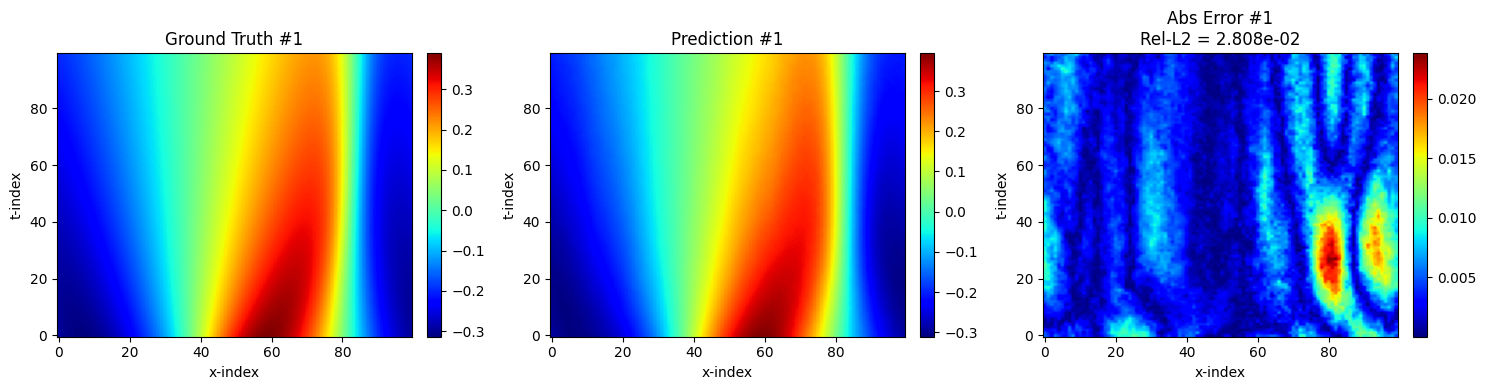

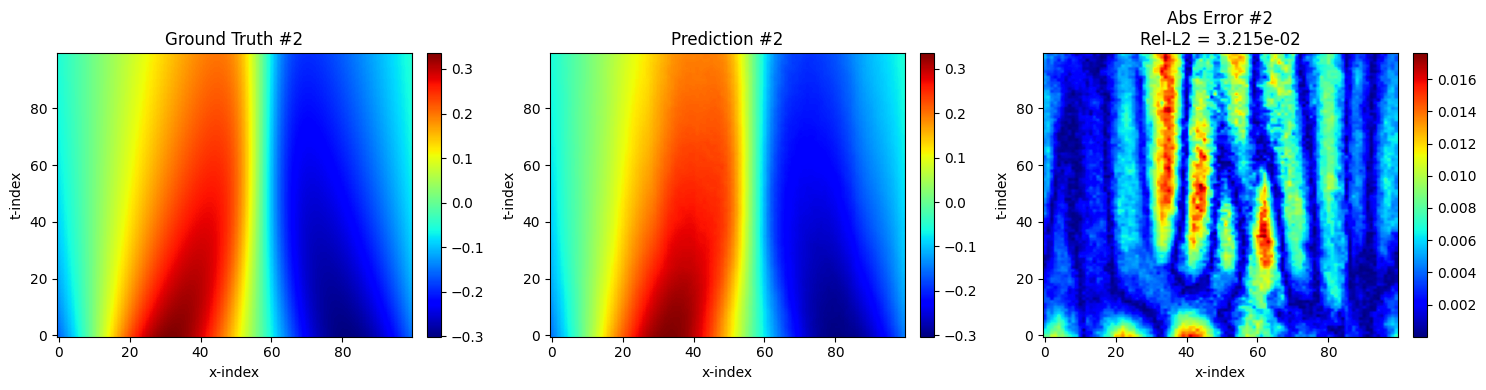

In [1]:
import os
import random
import math
from pathlib import Path

import numpy as np
import scipy.io
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ============================================================
# 1. Reproducibility
# ============================================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 2. Utility functions
# ============================================================
def relative_l2_error_np(gt: np.ndarray, pred: np.ndarray) -> float:
    num = np.linalg.norm(gt - pred)
    den = np.linalg.norm(gt)
    return float(num / (den + 1e-12))

def rel_l2_dataset_numpy(pred_all: np.ndarray, gt_all: np.ndarray) -> float:
    rels = [relative_l2_error_np(gt_all[i], pred_all[i]) for i in range(gt_all.shape[0])]
    return float(np.mean(rels))

def _resolve_ckpt_path(base_dir: Path, name: str) -> Path:
    ckpt_dir = base_dir / "checkpoints_fourier_sweep"
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    return ckpt_dir / f"{name}_best.pth"

def _safe_save_same_dir(obj, dest_path: Path):
    tmp_path = dest_path.with_suffix(dest_path.suffix + ".tmp")
    with open(tmp_path, "wb") as f:
        torch.save(obj, f)
    if dest_path.exists():
        try:
            os.remove(dest_path)
        except Exception:
            pass
    os.replace(str(tmp_path), str(dest_path))
    return str(dest_path)

# ============================================================
# 3. Load data
# ============================================================
data_path = "Burger.mat"
data_dir = Path(os.path.abspath(data_path)).parent

mat = scipy.io.loadmat(data_path)

# Expected keys from your original code
u_all = mat["input"]         # shape: [N, 100]
s_all = mat["output"]        # shape: [N, T, X]
s_all = s_all[:, :100, :]    # keep first 100 time points

N, T, X = s_all.shape
assert u_all.shape[0] == N and u_all.shape[1] == X == 100, "Unexpected data shape"

print("u_all shape:", u_all.shape)
print("s_all shape:", s_all.shape)

# ============================================================
# 4. Train / val / test split
# ============================================================
X_trainval, X_test, y_trainval, y_test = train_test_split(
    u_all, s_all, test_size=0.20, random_state=seed
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=seed
)
# This gives:
# train = 70%, val = 10%, test = 20%

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

# ============================================================
# 5. Normalization
# ============================================================
mu_ic = X_train.mean(axis=0, keepdims=True)
std_ic = X_train.std(axis=0, keepdims=True) + 1e-8

mu_sol = y_train.mean(axis=(0, 1), keepdims=True)
std_sol = y_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - mu_ic) / std_ic
X_val_n   = (X_val   - mu_ic) / std_ic
X_test_n  = (X_test  - mu_ic) / std_ic

y_train_n = (y_train - mu_sol) / std_sol
y_val_n   = (y_val   - mu_sol) / std_sol
y_test_n  = (y_test  - mu_sol) / std_sol

# ============================================================
# 6. Coordinates
# ============================================================
grid_x = np.linspace(0.0, 1.0, 100)
grid_t = np.linspace(0.0, 1.0, 100)

Xg, Tg = np.meshgrid(grid_x, grid_t, indexing="xy")
coords_np = np.stack([Xg, Tg], axis=-1).astype(np.float32)  # [100,100,2]

# ============================================================
# 7. Dataset / Dataloader
# ============================================================
class Burgers1DDataset(Dataset):
    def __init__(self, ic, sol, coords):
        self.ic = torch.tensor(ic, dtype=torch.float32)
        self.sol = torch.tensor(sol, dtype=torch.float32)
        self.coords = torch.tensor(coords, dtype=torch.float32)

    def __len__(self):
        return self.ic.shape[0]

    def __getitem__(self, i):
        return self.ic[i], self.sol[i]

train_ds = Burgers1DDataset(X_train_n, y_train_n, coords_np)
val_ds   = Burgers1DDataset(X_val_n,   y_val_n,   coords_np)
test_ds  = Burgers1DDataset(X_test_n,  y_test_n,  coords_np)

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

coords = train_ds.coords.to(device)   # [100,100,2]

# ============================================================
# 8. Model definitions
# ============================================================
class FourierEmbedding(nn.Module):
    def __init__(self, input_dim, mapping_size=64, sigma=10.0):
        super().__init__()
        B = torch.randn(input_dim, mapping_size) * sigma
        self.register_buffer("B", B)

    def forward(self, x):
        # x: [M, input_dim]
        x_proj = 2 * math.pi * x @ self.B   # [M, mapping_size]
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)  # [M, 2*mapping_size]

class TrunkFourier(nn.Module):
    def __init__(self, input_dim=2, mapping_size=64, sigma=10.0, hidden=256, out_features=100):
        super().__init__()
        self.embed = FourierEmbedding(input_dim=input_dim, mapping_size=mapping_size, sigma=sigma)
        self.net = nn.Sequential(
            nn.Linear(2 * mapping_size, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_features)
        )

    def forward(self, coords):
        x = coords.view(-1, 2)   # [10000,2]
        x = self.embed(x)        # [10000,2*mapping_size]
        return self.net(x)       # [10000,100]

class Branch(nn.Module):
    def __init__(self, out_features=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(100, 50), nn.ReLU(),
            nn.Linear(50, 50), nn.ReLU(),
            nn.Linear(50, 50), nn.ReLU(),
            nn.Linear(50, 50), nn.ReLU(),
            nn.Linear(50, 50), nn.ReLU(),
            nn.Linear(50, out_features)
        )

    def forward(self, ic):
        return self.net(ic)      # [B,100]

class DeepONet(nn.Module):
    def __init__(self, trunk, branch_out_features=100):
        super().__init__()
        self.branch = Branch(out_features=branch_out_features)
        self.trunk = trunk

    def forward(self, ic, coords):
        # ic: [B,100]
        # coords: [100,100,2]
        B = ic.size(0)
        G = coords.size(0)  # 100

        trunk_out = self.trunk(coords)     # [10000,100]
        branch_out = self.branch(ic)       # [B,100]

        y = torch.matmul(branch_out, trunk_out.T)  # [B,10000]
        return y.view(B, G, G)                     # [B,100,100]

# ============================================================
# 9. Denormalization
# ============================================================
def denorm_sol(y_norm: torch.Tensor) -> torch.Tensor:
    mu = torch.tensor(mu_sol, dtype=torch.float32, device=y_norm.device)
    sd = torch.tensor(std_sol, dtype=torch.float32, device=y_norm.device)
    return y_norm * sd + mu

# ============================================================
# 10. Train / eval functions
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, device, coords):
    model.train()
    run_loss = 0.0

    for ic, gt in loader:
        ic = ic.to(device)
        gt = gt.to(device)

        optimizer.zero_grad()
        pred = model(ic, coords)
        loss = criterion(pred, gt)
        loss.backward()
        optimizer.step()

        run_loss += loss.item() * ic.size(0)

    return run_loss / len(loader.dataset)

@torch.no_grad()
def val_rel_l2(model, loader, device, coords):
    model.eval()
    num_sq, den_sq = 0.0, 0.0

    for ic, gt in loader:
        ic = ic.to(device)
        gt = gt.to(device)

        pred = model(ic, coords)
        pred_d = denorm_sol(pred)
        gt_d = denorm_sol(gt)

        e = pred_d - gt_d
        num_sq += torch.sum(e ** 2).item()
        den_sq += torch.sum(gt_d ** 2).item()

    return math.sqrt(num_sq / (den_sq + 1e-20))

@torch.no_grad()
def evaluate_mean_rel_l2(model, loader, device, coords):
    model.eval()
    rels = []

    for ic, gt in loader:
        ic = ic.to(device)
        gt = gt.to(device)

        pred = model(ic, coords)
        pred_d = denorm_sol(pred).cpu().numpy()
        gt_d = denorm_sol(gt).cpu().numpy()

        for i in range(gt_d.shape[0]):
            rels.append(relative_l2_error_np(gt_d[i], pred_d[i]))

    return float(np.mean(rels))

@torch.no_grad()
def predict_fullset(model, loader, device, coords):
    model.eval()
    preds, gts, ics = [], [], []

    for ic, gt in loader:
        ic = ic.to(device)
        gt = gt.to(device)

        pred = model(ic, coords)

        pred_den = denorm_sol(pred).cpu().numpy()
        gt_den = denorm_sol(gt).cpu().numpy()

        preds.append(pred_den)
        gts.append(gt_den)
        ics.append(ic.cpu().numpy())

    return np.concatenate(ics), np.concatenate(gts), np.concatenate(preds)

def fit_model(model, name, train_loader, val_loader, coords, base_dir,
              max_epochs=1000, lr=1e-3, patience=150):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=30
    )

    best_val = float("inf")
    best_path = _resolve_ckpt_path(base_dir, name)
    wait = 0

    hist = {
        "train_loss": [],
        "val_rel_l2": []
    }

    print(f"[INFO] Saving checkpoint to: {best_path}")

    for epoch in range(1, max_epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, coords)
        val_r2 = val_rel_l2(model, val_loader, device, coords)

        hist["train_loss"].append(tr_loss)
        hist["val_rel_l2"].append(val_r2)

        scheduler.step(val_r2)

        print(f"[{name}] Epoch {epoch:4d}/{max_epochs} | Train MSE(n): {tr_loss:.6e} | Val Rel-L2: {val_r2:.6e}")

        if val_r2 < best_val - 1e-6:
            best_val = val_r2
            _safe_save_same_dir(
                {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "best_val_rel_l2": best_val
                },
                best_path
            )
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"[{name}] Early stopping at epoch {epoch}. Best Val Rel-L2: {best_val:.6e}")
                break

    return str(best_path), hist

# ============================================================
# 11. Fourier feature sweep
# ============================================================
def run_fourier_feature_sweep(
    mapping_sizes,
    sigma=10.0,
    hidden=256,
    out_features=100,
    max_epochs=1000,
    lr=1e-3,
    patience=150,
):
    results = {
        "mapping_size": [],
        "num_fourier_features": [],
        "best_val_rel_l2": [],
        "test_mean_rel_l2": [],
        "history": {}
    }

    for m in mapping_sizes:
        print("\n" + "=" * 90)
        print(f"Training FEDONet with mapping_size = {m} (actual Fourier feature dimension = {2*m})")
        print("=" * 90)

        # reset seeds for fairer comparison
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        model = DeepONet(
            TrunkFourier(
                input_dim=2,
                mapping_size=m,
                sigma=sigma,
                hidden=hidden,
                out_features=out_features
            ),
            branch_out_features=out_features
        ).to(device)

        ckpt_path, hist = fit_model(
            model=model,
            name=f"fedonet_ff_{m}",
            train_loader=train_loader,
            val_loader=val_loader,
            coords=coords,
            base_dir=data_dir,
            max_epochs=max_epochs,
            lr=lr,
            patience=patience
        )

        ckpt_data = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt_data["model_state"])

        best_val = float(ckpt_data["best_val_rel_l2"])
        test_rel = evaluate_mean_rel_l2(model, test_loader, device, coords)

        results["mapping_size"].append(m)
        results["num_fourier_features"].append(2 * m)
        results["best_val_rel_l2"].append(best_val)
        results["test_mean_rel_l2"].append(test_rel)
        results["history"][m] = hist

        print(f"[mapping_size={m}] Best Val Rel-L2  : {best_val:.6e}")
        print(f"[mapping_size={m}] Test Mean Rel-L2 : {test_rel:.6e}")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return results

# ============================================================
# 12. Run the sweep
# ============================================================
# mapping_size = m means actual Fourier embedding dimension = 2*m
mapping_sizes = [4, 8, 16, 32, 64, 128, 256]

# Your old 9000-epoch setup is excessive for a sweep.
# Start with this. If needed, rerun with more epochs near the best region.
sweep_results = run_fourier_feature_sweep(
    mapping_sizes=mapping_sizes,
    sigma=10.0,
    hidden=256,
    out_features=100,
    max_epochs=2200,
    lr=1e-3,
    patience=15000,
)

# ============================================================
# 13. Summary
# ============================================================
mapping_sizes_arr  = np.array(sweep_results["mapping_size"])
num_features_arr   = np.array(sweep_results["num_fourier_features"])
best_val_arr       = np.array(sweep_results["best_val_rel_l2"])
test_mean_rel2_arr = np.array(sweep_results["test_mean_rel_l2"])

print("\n" + "=" * 90)
print("Sweep Summary")
print("=" * 90)
for m, nf, v, t in zip(mapping_sizes_arr, num_features_arr, best_val_arr, test_mean_rel2_arr):
    print(f"mapping_size = {m:4d} | # Fourier features = {nf:4d} | Best Val Rel-L2 = {v:.6e} | Test Mean Rel-L2 = {t:.6e}")

best_idx = np.argmin(test_mean_rel2_arr)
best_m = mapping_sizes_arr[best_idx]
best_nf = num_features_arr[best_idx]
best_test = test_mean_rel2_arr[best_idx]

print("\nBest model based on test mean Rel-L2:")
print(f"mapping_size = {best_m}, # Fourier features = {best_nf}, test mean Rel-L2 = {best_test:.6e}")

# ============================================================
# 14. Plot: convergence of Rel-L2 vs Fourier features
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(num_features_arr, best_val_arr, marker='o', linewidth=2, label='Best Validation Rel-L2')
plt.plot(num_features_arr, test_mean_rel2_arr, marker='s', linewidth=2, label='Test Mean Rel-L2')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Number of Fourier features (2 × mapping_size)', fontsize=13)
plt.ylabel('Relative L2 Error', fontsize=13)
plt.title('Convergence of Rel-L2 Error with Fourier Features', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ============================================================
# 15. Optional: plot training histories for all sweeps
# ============================================================
plt.figure(figsize=(9, 6))
for m in mapping_sizes:
    hist = sweep_results["history"][m]
    plt.plot(hist["val_rel_l2"], linewidth=2, label=f"m={m} (2m={2*m})")
plt.yscale("log")
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Validation Rel-L2", fontsize=13)
plt.title("Validation Rel-L2 History for Different Fourier Features", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ============================================================
# 16. Reload the best model and inspect test predictions
# ============================================================
best_ckpt_path = _resolve_ckpt_path(data_dir, f"fedonet_ff_{best_m}")
best_model = DeepONet(
    TrunkFourier(
        input_dim=2,
        mapping_size=int(best_m),
        sigma=10.0,
        hidden=256,
        out_features=100
    ),
    branch_out_features=100
).to(device)

best_ckpt_data = torch.load(best_ckpt_path, map_location=device)
best_model.load_state_dict(best_ckpt_data["model_state"])

IC_test, GT_test, PRED_test = predict_fullset(best_model, test_loader, device, coords)

sample_rel2 = np.array([
    relative_l2_error_np(GT_test[i], PRED_test[i]) for i in range(GT_test.shape[0])
])

print(f"\nReloaded best model test mean Rel-L2: {sample_rel2.mean():.6e}")
print(f"Reloaded best model test std  Rel-L2: {sample_rel2.std():.6e}")

# ============================================================
# 17. Show a few test predictions
# ============================================================
n_show = min(3, GT_test.shape[0])

for idx in range(n_show):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axes[0].imshow(GT_test[idx], aspect='auto', origin='lower', cmap='jet')
    axes[0].set_title(f"Ground Truth #{idx}")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(PRED_test[idx], aspect='auto', origin='lower', cmap='jet')
    axes[1].set_title(f"Prediction #{idx}")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    err = np.abs(GT_test[idx] - PRED_test[idx])
    im2 = axes[2].imshow(err, aspect='auto', origin='lower', cmap='jet')
    axes[2].set_title(f"Abs Error #{idx}\nRel-L2 = {sample_rel2[idx]:.3e}")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xlabel("x-index")
        ax.set_ylabel("t-index")

    plt.tight_layout()
    plt.show()

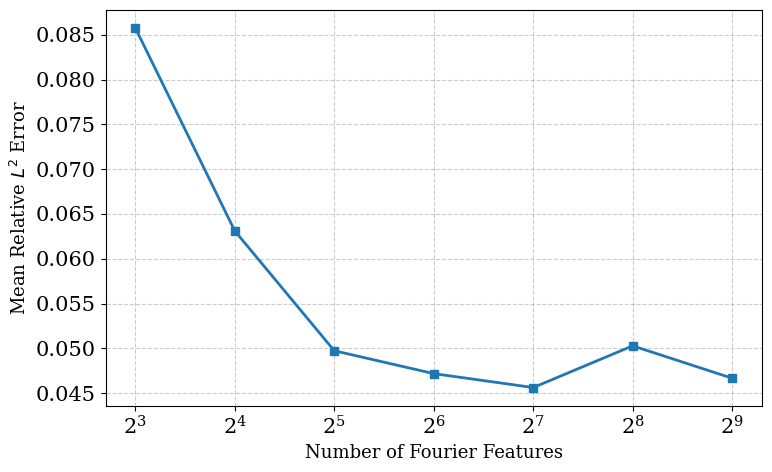

In [3]:
import matplotlib as mpl


def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})

plt.figure(figsize=(8, 5))
plt.plot(num_features_arr, test_mean_rel2_arr, marker='s', linewidth=2, label='Test Mean Rel-L2')
plt.xscale('log', base=2)
# plt.yscale('log')
plt.xlabel('Number of Fourier Features', fontsize=13)
plt.ylabel('Mean Relative $L^2$ Error', fontsize=13)
# plt.title('Convergence of Rel-L2 Error with Fourier Features', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
# plt.legend(fontsize=11)
plt.tight_layout()
plt.show()